In [60]:
using HyQMOM, OrdinaryDiffEq, Plots, CSV, Tables, LinearAlgebra, LaTeXStrings

In [66]:
# Parameter
M_vector = [4, 6, 8, 10, 12]    # number of moments
Kn = 1.0  # Knudsen number
T_end = 0.3

ρ_L = 7.0; v_L = 0.0; θ_L = 1.0
ρ_R = 1.0; v_R = 0.0; θ_R = 1.0

# χ value -> Gauge for χ = (n+1)/n with n = M/2
χ_vector = [-1.0, 0.0, 1.0, "optimal", 1.5, 2.0, 3.0]

7-element Vector{Any}:
 -1.0
  0.0
  1.0
   "optimal"
  1.5
  2.0
  3.0

In [67]:
θ_solutions = Dict()
for χ in χ_vector
    for (i, M) in enumerate(M_vector)
        if χ == "optimal"
            name = "ChiGauge/gram_solution_M$(M)_Kn$(Kn)_T_end$(T_end)_rho_L$(ρ_L)_rho_R$(ρ_R)_v_L$(v_L)_v_R$(v_R)_theta_L$(θ_L)_theta_R$(θ_R)"
        else
            name = "Chi$(χ)/gram_solution_M$(M)_Kn$(Kn)_T_end$(T_end)_rho_L$(ρ_L)_rho_R$(ρ_R)_v_L$(v_L)_v_R$(v_R)_theta_L$(θ_L)_theta_R$(θ_R)"
        end
        solution_file = "../out/Convergence/ChiValues/$(name).tsv"

        # Load the solutions and plot θ
        x, conservative_moments = readfile(solution_file)
        primitive_moments = similar(conservative_moments)
        for i in 1:size(conservative_moments, 2)
            primitive_moments[:, i] = moment_cons2prim(conservative_moments[:, i])
        end

        # store the θ solution
        θ_solutions[(M, χ)] = (x, primitive_moments[3, :])
    end
end

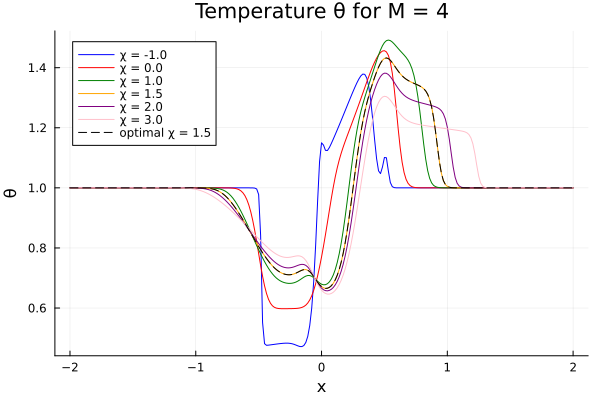

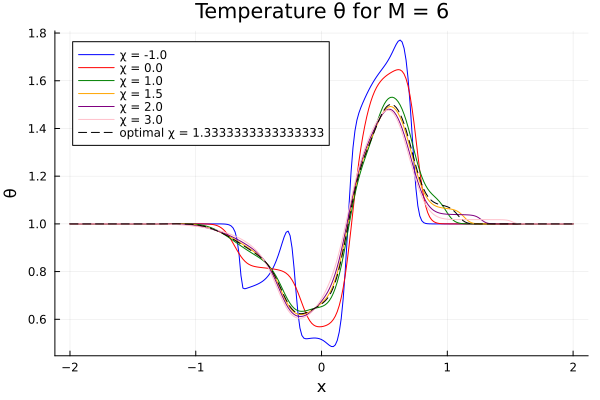

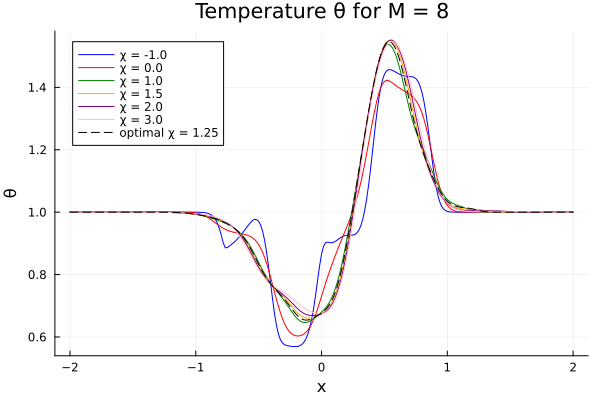

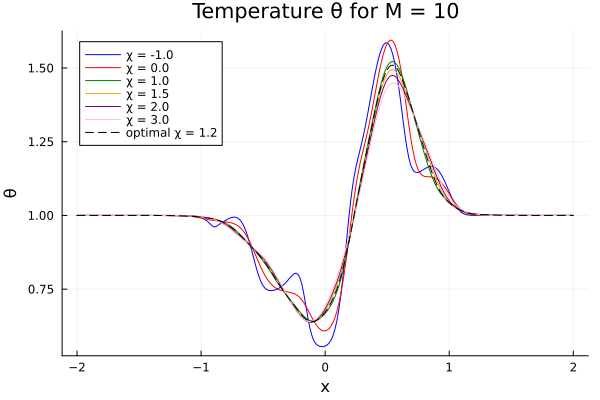

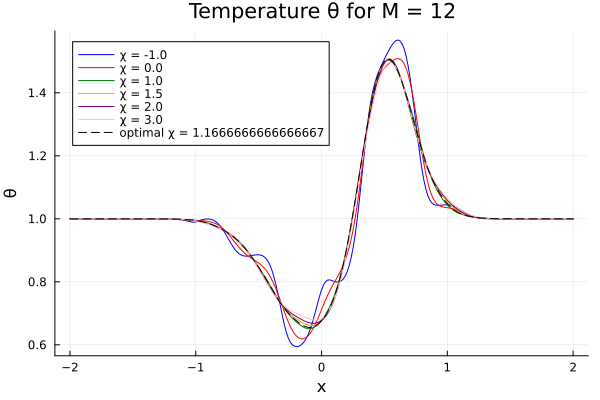

In [78]:
colors = [:blue, :red, :green, :orange, :purple, :pink]

p = []
for _ in 1:length(M_vector)
    push!(p, plot())
end
for χ in χ_vector
    for (i, M) in enumerate(M_vector)
        x, θ = θ_solutions[(M, χ)]
        if χ == "optimal"
            continue
            # plot!(p[i], x, θ, label = "χ = optimal", color = :black, linestyle = :dash)
        else
            plot!(p[i], x, θ, label = "χ = $(χ)", color = colors[findfirst(==(χ), χ_vector)])
        end
    end
end
for (i, M) in enumerate(M_vector)
    x_opt, θ_opt = θ_solutions[(M, "optimal")]
    n = Int(M/2)
    χ_Gauge = (n+1)/n
    plot!(p[i], x_opt, θ_opt, label = "optimal χ = $(χ_Gauge)", color = :black, linestyle = :dash)
end
for (i, M) in enumerate(M_vector)
    plot!(p[i], title = "Temperature θ for M = $(M)", xlabel = "x", ylabel = "θ", legend = :topleft)
    display(p[i])
end

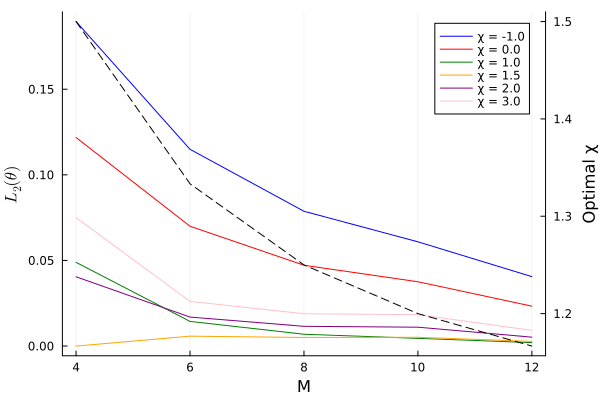

In [73]:
# Convergence towards χ = optimal
p = plot()
for χ in filter!(e->e≠"optimal", χ_vector)
    L2_error = []
    for (i, M) in enumerate(M_vector)
        x, θ = θ_solutions[(M, χ)]
        x_opt, θ_opt = θ_solutions[(M, "optimal")]
        push!(L2_error, norm(θ .- θ_opt, 2) / norm(θ_opt, 2))
    end
    plot!(p, M_vector, L2_error, label = "χ = $(χ)", color = colors[findfirst(==(χ), χ_vector)])
end
xlabel!(p, "M")
ylabel!(p, L"L_2(\theta)")

# Optimal χ values
χ_optimal = []
for M in M_vector
    n = Int(M/2)
    push!(χ_optimal, (n+1)/n)
end

plot!(twinx(p), M_vector, χ_optimal, label="", yaxis= "Optimal χ", color = :black, linestyle = :dash)
display(p)